In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,Input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
dataset_path = "Garbage classification"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Classes:", train_dataset.class_names)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
classes = train_dataset.class_names

train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))

validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))

In [6]:
model = Sequential()

model.add(Input(shape=(128, 128, 3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(6, activation='softmax'))

In [7]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,246 (14.14 MB)

 Trainable params: 3,706,246 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.fit(train_dataset,epochs=5,validation_data=validation_dataset)

loss, accuracy = model.evaluate(validation_dataset)

print("Accuracy:", accuracy)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - accuracy: 0.3368 - loss: 1.5836 - val_accuracy: 0.4871 - val_loss: 1.3328
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.4753 - loss: 1.3453 - val_accuracy: 0.5327 - val_loss: 1.2551
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.5124 - loss: 1.2308 - val_accuracy: 0.5921 - val_loss: 1.1503
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.5673 - loss: 1.1354 - val_accuracy: 0.5921 - val_loss: 1.1109
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.6306 - loss: 0.9994 - val_accuracy: 0.6198 - val_loss: 1.0486
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6198 - loss: 1.0486
Accuracy: 0.6198019981384277


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
Image 1
Actual    : glass
Predicted : glass
------------------------------


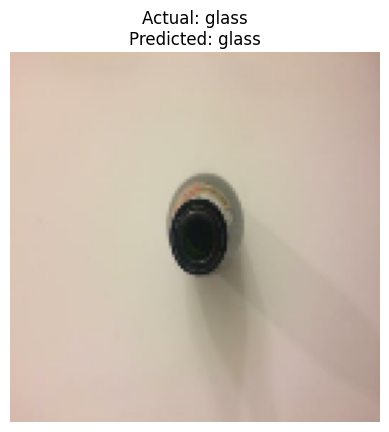

Image 2
Actual    : trash
Predicted : glass
------------------------------


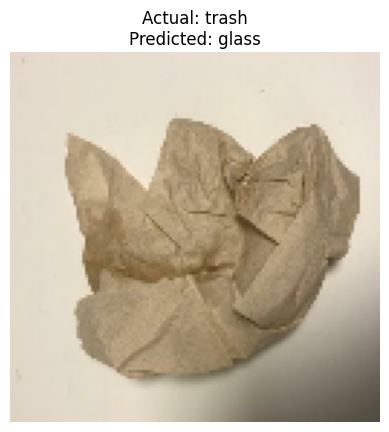

Image 3
Actual    : glass
Predicted : plastic
------------------------------


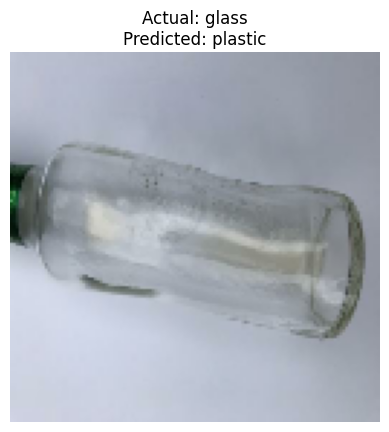

Image 4
Actual    : plastic
Predicted : plastic
------------------------------


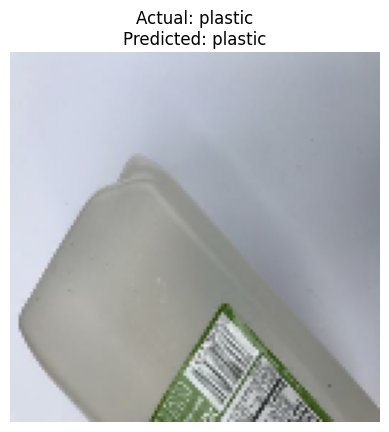

Image 5
Actual    : glass
Predicted : glass
------------------------------


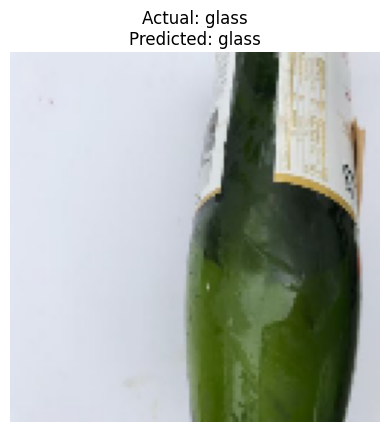

In [11]:
images, labels = next(iter(validation_dataset))

predictions = model.predict(images[:5])

for i in range(5):

    predicted_label = np.argmax(predictions[i])

    actual_label = labels[i].numpy()

    print(f"Image {i+1}")
    print(f"Actual    : {classes[actual_label]}")
    print(f"Predicted : {classes[predicted_label]}")
    print("-" * 30)

    plt.imshow(images[i])

    plt.title(f"Actual: {classes[actual_label]}\n"f"Predicted: {classes[predicted_label]}")

    plt.axis("off")
    plt.show()